In [22]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import xarray as xr
import numpy as np
import os
# import pandas as pd
from glob import glob
#import climpredNEW.climpred 
#from climpredNEW.climpred.options import OPTIONS
from climpred.options import OPTIONS
import climpred
import pickle
from mpl_toolkits.basemap import Basemap
from numpy import meshgrid
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib.colors as mcolors
import cartopy.feature as cfeature
import itertools
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LatitudeLocator
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, TwoSlopeNorm
from scipy.stats import rankdata
import bottleneck as bn
import scipy.stats as stats
from pathlib import Path

from function import preprocessUtils as putils
from function import masks
from function import verifications
from function import funs as f
from function import conf
from function import loadbias
from function import dataLoad
from function import quikplot as qp


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load regions


In [2]:
region_name = 'CONUS' #or ['australia', 'CONUS', 'china']
obs_source = 'GLEAM' #['ERA5','GLEAM']

if obs_source == 'ERA5':
    soil_dir = conf.era_data
elif obs_source == 'GLEAM':
    soil_dir = conf.gleam_data



# Need the raw soil moisture from observations (no anomaly)

In [3]:
global obs_original,obs_raw
#USE OBS_ORIGINAL
obs_original,obs_raw = dataLoad.load_rzsm_observations(soil_dir, region_name)
obs_original["time"] = obs_original["time"].dt.floor("D")
obs_raw["time"] = obs_raw["time"].dt.floor("D")

if region_name == 'CONUS' and obs_source=='ERA5':
    obs_original = obs_original.rename({'X':'longitude','Y':'latitude'})

obs_anom_climp = verifications.rename_obs_for_climpred(obs_original)

mask, mask_anom = masks.load_mask_vals(region_name)

In [70]:
obs_anom_climp

<xarray.Dataset> Size: 143MB
Dimensions:  (time: 7731, lat: 48, lon: 96)
Coordinates:
  * time     (time) datetime64[ns] 62kB 1999-01-01 1999-01-02 ... 2020-03-01
  * lon      (lon) float64 768B 238.0 238.5 239.0 239.5 ... 284.5 285.0 285.5
  * lat      (lat) float64 384B 50.0 49.5 49.0 48.5 48.0 ... 28.0 27.5 27.0 26.5
Data variables:
    RZSM     (time, lat, lon) float32 142MB nan nan nan nan ... nan nan nan nan

# Get all init dates

In [6]:


start_obs = '2000-01-01' #Beginning of observation period for analysis. We actually have data starting from 1999 so that we could have a 7-day rolling mean applied to the data and have up to 12 weeks lags for RZSM
end_obs = '2020-12-31' #end of observations for ERA5 and GLEAM. We actually needed data through 2020-02-15 since we have an initialization on 2019-12-25
start_testing = '2018-01-01' #Beginning of testing period
end_testing = '2019-12-31'
train_end_string = '2015-12-31' #last string date for training
train_end = 2015 #last year of training dates


global RZSM_or_Tmax_or_both
RZSM_or_Tmax_or_both = 'RZSM' # for getting the predictor from either RZSM and Tmax ('both') or only RZSM ('RZSM')

lead_select = [6,13,20,27]

init_dates,dt_dates,only_testing_dates = dataLoad.return_init_and_testing_dates(region_name,start_testing,end_testing)

In [49]:
init_dates[0:10]
print(len(init_dates))
print(init_dates[700:])

1043
['2013-06-05', '2013-06-12', '2013-06-19', '2013-06-26', '2013-07-03', '2013-07-10', '2013-07-17', '2013-07-24', '2013-07-31', '2013-08-07', '2013-08-14', '2013-08-21', '2013-08-28', '2013-09-04', '2013-09-11', '2013-09-18', '2013-09-25', '2013-10-02', '2013-10-09', '2013-10-16', '2013-10-23', '2013-10-30', '2013-11-06', '2013-11-13', '2013-11-20', '2013-11-27', '2013-12-04', '2013-12-11', '2013-12-18', '2013-12-25', '2014-01-01', '2014-01-08', '2014-01-15', '2014-01-22', '2014-01-29', '2014-02-05', '2014-02-12', '2014-02-19', '2014-02-26', '2014-03-05', '2014-03-12', '2014-03-19', '2014-03-26', '2014-04-02', '2014-04-09', '2014-04-16', '2014-04-23', '2014-04-30', '2014-05-07', '2014-05-14', '2014-05-21', '2014-05-28', '2014-06-04', '2014-06-11', '2014-06-18', '2014-06-25', '2014-07-02', '2014-07-09', '2014-07-16', '2014-07-23', '2014-07-30', '2014-08-06', '2014-08-13', '2014-08-20', '2014-08-27', '2014-09-03', '2014-09-10', '2014-09-17', '2014-09-24', '2014-10-01', '2014-10-08', 

In [50]:
from datetime import datetime, timedelta
new_dates = []
for d in init_dates:
    nd = datetime.strptime(d, '%Y-%m-%d') - timedelta(days=2)
    # if it lands on Feb-29, push it back to Feb-28 instead
    if nd.month == 2 and nd.day == 29:
        nd = nd.replace(day=28)
    new_dates.append(nd.strftime('%Y-%m-%d'))

print(new_dates)


['2000-01-03', '2000-01-10', '2000-01-17', '2000-01-24', '2000-01-31', '2000-02-07', '2000-02-14', '2000-02-21', '2000-02-28', '2000-03-06', '2000-03-13', '2000-03-20', '2000-03-27', '2000-04-03', '2000-04-10', '2000-04-17', '2000-04-24', '2000-05-01', '2000-05-08', '2000-05-15', '2000-05-22', '2000-05-29', '2000-06-05', '2000-06-12', '2000-06-19', '2000-06-26', '2000-07-03', '2000-07-10', '2000-07-17', '2000-07-24', '2000-07-31', '2000-08-07', '2000-08-14', '2000-08-21', '2000-08-28', '2000-09-04', '2000-09-11', '2000-09-18', '2000-09-25', '2000-10-02', '2000-10-09', '2000-10-16', '2000-10-23', '2000-10-30', '2000-11-06', '2000-11-13', '2000-11-20', '2000-11-27', '2000-12-04', '2000-12-11', '2000-12-18', '2000-12-25', '2001-01-01', '2001-01-08', '2001-01-15', '2001-01-22', '2001-01-29', '2001-02-05', '2001-02-12', '2001-02-19', '2001-02-26', '2001-03-05', '2001-03-12', '2001-03-19', '2001-03-26', '2001-04-02', '2001-04-09', '2001-04-16', '2001-04-23', '2001-04-30', '2001-05-07', '2001

In [52]:
base_dir = f'{conf.ecmwf_data}/{region_name}/soilw_bgrnd'
base_dir

'/glade/derecho/scratch/klesinger/FD_RZSM_deep_learning/Data/reforecast/ECMWF/CONUS/soilw_bgrnd'

# Now open the new files for different dates and the files for the actual init dates

In [53]:
files

['/glade/derecho/scratch/klesinger/FD_RZSM_deep_learning/Data/reforecast/ECMWF/CONUS/soilw_bgrnd/soilw_bgrnd_2000-01-03.nc',
 '/glade/derecho/scratch/klesinger/FD_RZSM_deep_learning/Data/reforecast/ECMWF/CONUS/soilw_bgrnd/soilw_bgrnd_2000-01-10.nc',
 '/glade/derecho/scratch/klesinger/FD_RZSM_deep_learning/Data/reforecast/ECMWF/CONUS/soilw_bgrnd/soilw_bgrnd_2000-01-17.nc',
 '/glade/derecho/scratch/klesinger/FD_RZSM_deep_learning/Data/reforecast/ECMWF/CONUS/soilw_bgrnd/soilw_bgrnd_2000-01-24.nc',
 '/glade/derecho/scratch/klesinger/FD_RZSM_deep_learning/Data/reforecast/ECMWF/CONUS/soilw_bgrnd/soilw_bgrnd_2000-01-31.nc',
 '/glade/derecho/scratch/klesinger/FD_RZSM_deep_learning/Data/reforecast/ECMWF/CONUS/soilw_bgrnd/soilw_bgrnd_2000-02-07.nc',
 '/glade/derecho/scratch/klesinger/FD_RZSM_deep_learning/Data/reforecast/ECMWF/CONUS/soilw_bgrnd/soilw_bgrnd_2000-02-14.nc',
 '/glade/derecho/scratch/klesinger/FD_RZSM_deep_learning/Data/reforecast/ECMWF/CONUS/soilw_bgrnd/soilw_bgrnd_2000-02-21.nc',


In [55]:
# New dates
files = [
    f"{base_dir}/soilw_bgrnd_{d}.nc"
    for d in new_dates
]

# Open individual xarray datasets from the files
datasets = [xr.open_dataset(file) for file in files]
ecmwf_minus_2 = xr.concat(datasets, dim='S', combine_attrs="override")


In [58]:
# Old dates
files = [
    f"{base_dir}/soilw_bgrnd_{d}.nc"
    for d in init_dates
]
# Open individual xarray datasets from the files
datasets = [xr.open_dataset(file) for file in files]
ecmwf_regular = xr.concat(datasets, dim='S', combine_attrs="override")

# Now we need to remove the first 2 days from ECMWF_minus_2 because they are 2 days before the actual init dates

In [65]:
ecmwf_minus_2_corrected = ecmwf_minus_2.isel(L=slice(2, None))
ecmwf_minus_2_corrected['L'] = np.arange(43)

#complete

In [60]:
ecmwf_regular

<xarray.Dataset> Size: 10GB
Dimensions:  (S: 1043, M: 11, L: 45, Y: 48, X: 96)
Coordinates:
  * X        (X) float64 768B 238.0 238.5 239.0 239.5 ... 284.5 285.0 285.5
  * Y        (Y) float64 384B 50.0 49.5 49.0 48.5 48.0 ... 28.0 27.5 27.0 26.5
  * L        (L) int64 360B 0 1 2 3 4 5 6 7 8 9 ... 36 37 38 39 40 41 42 43 44
  * M        (M) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * S        (S) datetime64[ns] 8kB 2000-01-05 2000-01-12 ... 2019-12-25
Data variables:
    RZSM     (S, M, L, Y, X) float32 10GB 0.3745 0.3745 0.3745 ... 0.0 0.0 0.0

In [74]:
ecmwf_minus_2_climp = verifications.rename_subx_for_climpred(ecmwf_minus_2_corrected)
ecmwf_regular_climp = verifications.rename_subx_for_climpred(ecmwf_regular)
obs_climp = verifications.rename_obs_for_climpred(obs_original)

In [81]:
ecmwf_minus_2_final = verifications.create_climpred_ACC_no_chunk(ecmwf_minus_2_climp, obs_climp)


In [92]:
ecmwf_minus_2_final.isel(lead=5).mean()

<xarray.Dataset> Size: 56B
Dimensions:  ()
Coordinates:
    lead     int64 8B 5
    skill    <U11 44B 'initialized'
Data variables:
    acc      float32 4B 0.4378

/glade/derecho/scratch/klesinger/tmp/ipykernel_15807/3348850241.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


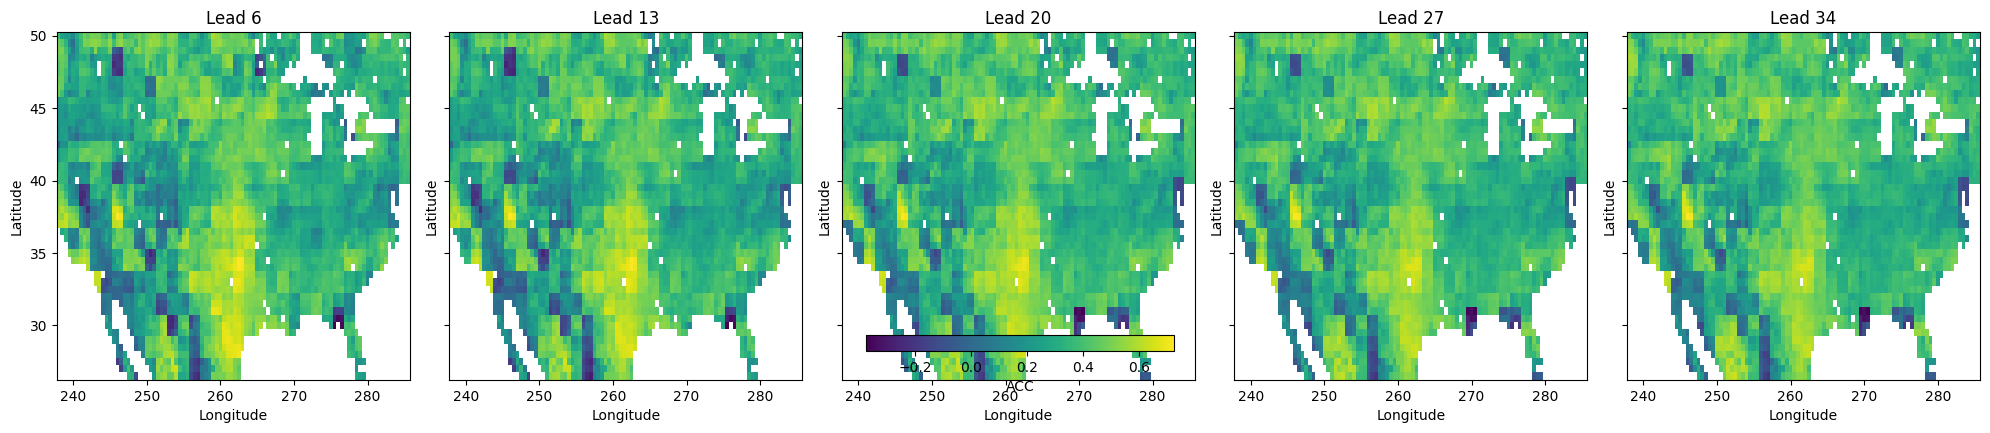

In [82]:
import matplotlib.pyplot as plt

# Ensure 'ecmwf_minus_2' is in your namespace and has a data variable 'acc'
leads_to_plot = [6, 13, 20, 27, 34]

fig, axes = plt.subplots(1, len(leads_to_plot), figsize=(20, 4), sharex=True, sharey=True)

for ax, lead in zip(axes, leads_to_plot):
    da = ecmwf_minus_2_final.acc.sel(lead=lead)
    im = ax.pcolormesh(da.lon, da.lat, da, shading='auto')
    ax.set_title(f'Lead {lead}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Add a single colorbar for all subplots
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('ACC')

plt.tight_layout()
plt.show()

In [76]:
ecmwf_regular_final = verifications.create_climpred_ACC_no_chunk(ecmwf_regular_climp, obs_climp)

/glade/derecho/scratch/klesinger/tmp/ipykernel_15807/3054811254.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


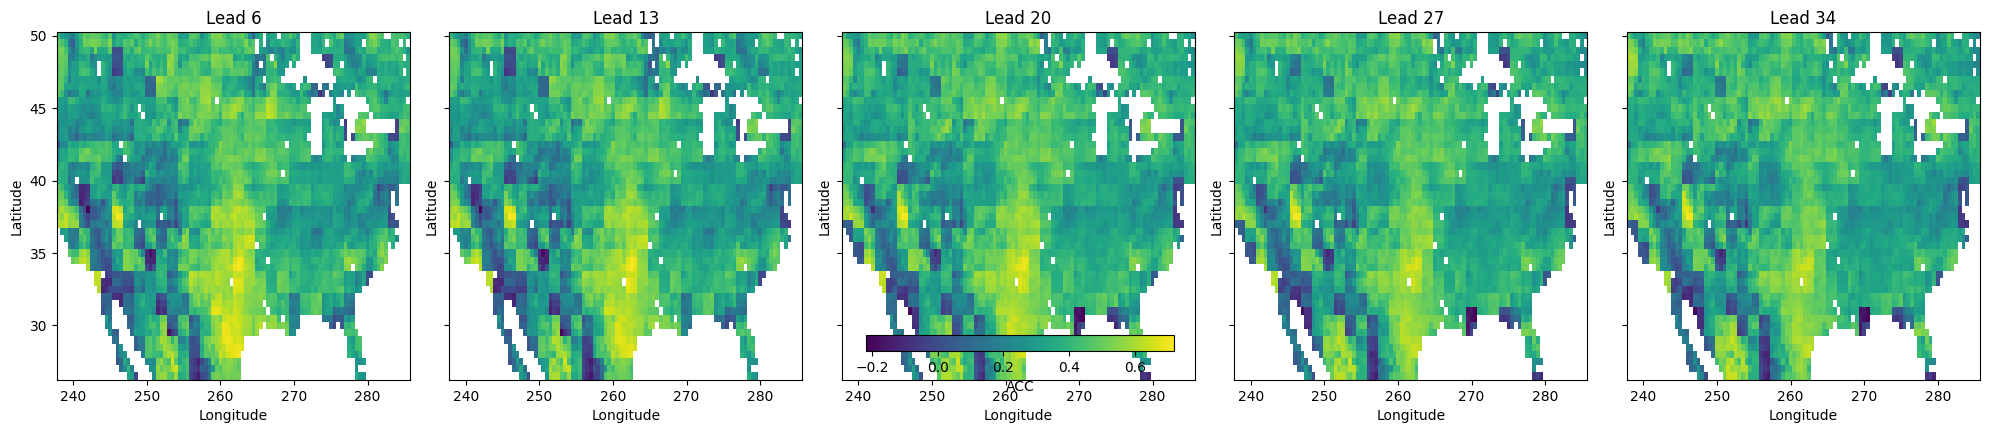

In [83]:
import matplotlib.pyplot as plt

# Ensure 'ecmwf_minus_2' is in your namespace and has a data variable 'acc'
leads_to_plot = [6, 13, 20, 27, 34]

fig, axes = plt.subplots(1, len(leads_to_plot), figsize=(20, 4), sharex=True, sharey=True)

for ax, lead in zip(axes, leads_to_plot):
    da = ecmwf_regular_final.acc.sel(lead=lead)
    im = ax.pcolormesh(da.lon, da.lat, da, shading='auto')
    ax.set_title(f'Lead {lead}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# Add a single colorbar for all subplots
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
cbar.set_label('ACC')

plt.tight_layout()
plt.show()

In [77]:
ecmwf_regular_final

<xarray.Dataset> Size: 831kB
Dimensions:  (lead: 45, lat: 48, lon: 96)
Coordinates:
  * lead     (lead) int64 360B 0 1 2 3 4 5 6 7 8 ... 36 37 38 39 40 41 42 43 44
  * lon      (lon) float64 768B 238.0 238.5 239.0 239.5 ... 284.5 285.0 285.5
  * lat      (lat) float64 384B 50.0 49.5 49.0 48.5 48.0 ... 28.0 27.5 27.0 26.5
    skill    <U11 44B 'initialized'
Data variables:
    acc      (lead, lat, lon) float32 829kB 0.4975 0.3812 0.3528 ... nan nan nan
Attributes:
    lead:                          days
    prediction_skill_software:     climpred https://climpred.readthedocs.io/
    skill_calculated_by_function:  HindcastEnsemble.verify()
    number_of_initializations:     1043
    number_of_members:             11
    alignment:                     same_inits
    metric:                        pearson_r
    comparison:                    e2o
    dim:                           init
    reference:                     []

# Now substract the 2 to identify how much loss of skill we get by subtracting 2 days

In [103]:
final_plot =  ecmwf_minus_2_final - ecmwf_regular_final
final_plot

<xarray.Dataset> Size: 794kB
Dimensions:  (lead: 43, lon: 96, lat: 48)
Coordinates:
  * lead     (lead) int64 344B 0 1 2 3 4 5 6 7 8 ... 34 35 36 37 38 39 40 41 42
  * lon      (lon) float64 768B 238.0 238.5 239.0 239.5 ... 284.5 285.0 285.5
  * lat      (lat) float64 384B 50.0 49.5 49.0 48.5 48.0 ... 28.0 27.5 27.0 26.5
    skill    <U11 44B 'initialized'
Data variables:
    acc      (lead, lat, lon) float32 793kB -0.009269 -0.02577 ... nan nan

/glade/derecho/scratch/klesinger/tmp/ipykernel_15807/1413943002.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 0.95])


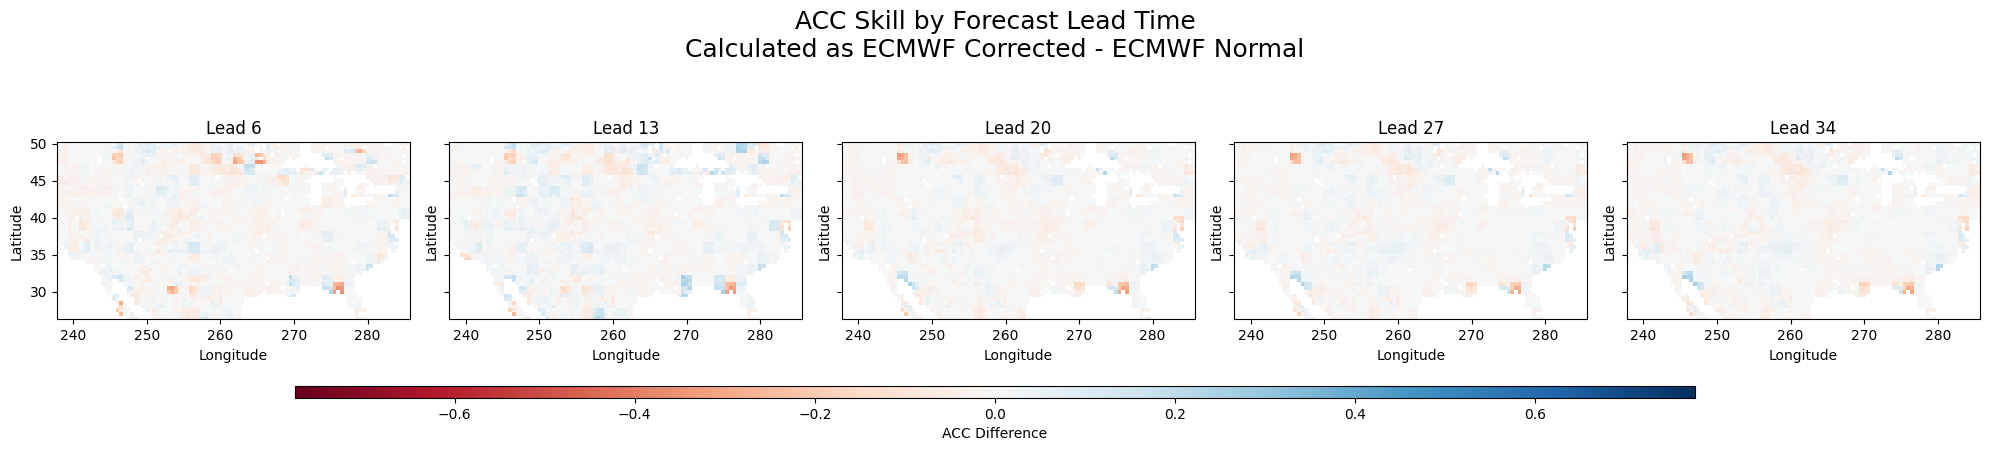

In [107]:
import matplotlib.pyplot as plt

save_dir = 'Outputs/ECMWF_ACC_diff'
os.makedirs(save_dir, exist_ok=True)

# Use the correct dataset name here
ds = final_plot
leads_to_plot = [6, 13, 20, 27, 34]

# Determine symmetric range around zero for the colormap
vmin = float(ds.acc.min())
vmax = float(ds.acc.max())
max_abs = max(abs(vmin), abs(vmax))
norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

fig, axes = plt.subplots(1, len(leads_to_plot), figsize=(20, 4), sharex=True, sharey=True)

for ax, lead in zip(axes, leads_to_plot):
    da = ds.acc.sel(lead=lead)
    im = ax.pcolormesh(da.lon, da.lat, da, shading='auto', cmap='RdBu', norm=norm)
    ax.set_title(f'Lead {lead}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

# super‐title for the whole figure
fig.suptitle('ACC Skill by Forecast Lead Time\nCalculated as ECMWF Corrected - ECMWF Normal', fontsize=18, y=1.02)

# Create a wider colorbar below the plots
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('ACC Difference')

# adjust layout: leave space at bottom for cbar and at top for suptitle
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.savefig(f'{save_dir}/ACC_difference_in_init_dates.png',dpi=300)
plt.show()